Calabines Ayden Jarrick J. <br>
CPE 313-CPE32S3 - Advanced Machine Learning and Deep Learning <br>
Assessment Task 4.1 Supplementary Activity on Transfer Learning 

------

In [13]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

In [16]:
base_path = r"C:\Users\Mong\Desktop\Eden\Hands-on Activity 4.1 Introduction to Pytorch\dataset"

train_data = datasets.ImageFolder(os.path.join(base_path,"train"), transform=train_transform)
val_data = datasets.ImageFolder(os.path.join(base_path,"val"), transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

In [17]:
model = models.resnet18(pretrained=True)

# Freeze early layers; fine-tune layer4 + FC
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Replace final FC layer for 3 classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

model = model.to(device)

In [18]:
weights = torch.tensor([1.0, 1.0, 1.0]).to(device)  # adjust if needed
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [19]:
num_epochs = 20
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")  # save best model

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")

print(f"✅ Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch [1/20] | Loss: 1.0617 | Val Accuracy: 61.99%
Epoch [2/20] | Loss: 0.7886 | Val Accuracy: 61.40%
Epoch [3/20] | Loss: 0.5886 | Val Accuracy: 63.16%
Epoch [4/20] | Loss: 0.5420 | Val Accuracy: 70.76%
Epoch [5/20] | Loss: 0.4470 | Val Accuracy: 62.57%
Epoch [6/20] | Loss: 0.3905 | Val Accuracy: 61.99%
Epoch [7/20] | Loss: 0.3612 | Val Accuracy: 63.74%
Epoch [8/20] | Loss: 0.3449 | Val Accuracy: 61.99%
Epoch [9/20] | Loss: 0.3075 | Val Accuracy: 64.91%
Epoch [10/20] | Loss: 0.2813 | Val Accuracy: 69.01%
Epoch [11/20] | Loss: 0.3028 | Val Accuracy: 66.08%
Epoch [12/20] | Loss: 0.2646 | Val Accuracy: 68.42%
Epoch [13/20] | Loss: 0.2665 | Val Accuracy: 67.25%
Epoch [14/20] | Loss: 0.2748 | Val Accuracy: 66.08%
Epoch [15/20] | Loss: 0.2630 | Val Accuracy: 66.67%
Epoch [16/20] | Loss: 0.2451 | Val Accuracy: 67.25%
Epoch [17/20] | Loss: 0.2677 | Val Accuracy: 67.25%
Epoch [18/20] | Loss: 0.2662 | Val Accuracy: 67.84%
Epoch [19/20] | Loss: 0.2708 | Val Accuracy: 66.67%
Epoch [20/20] | Loss:

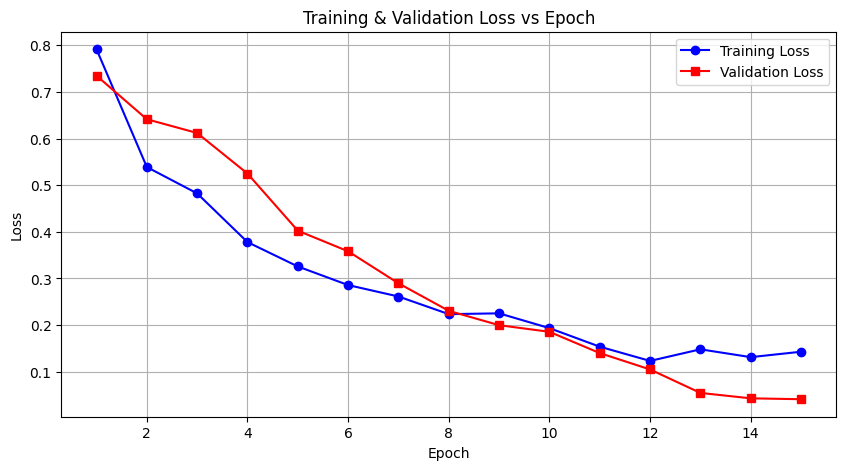

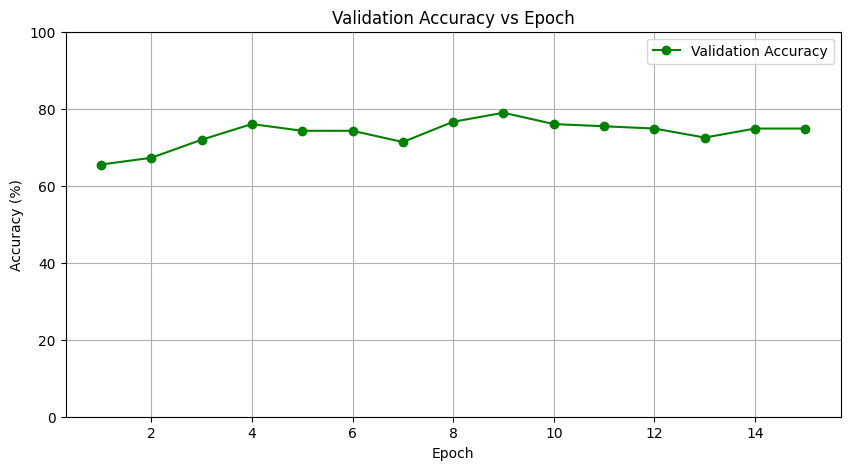

In [21]:
import matplotlib.pyplot as plt

train_losses = [0.7914, 0.5388, 0.4823, 0.3779, 0.3257, 0.2858, 0.2613,
                0.2235, 0.2252, 0.1935, 0.1537, 0.1232, 0.1481, 0.1313, 0.1429]
val_losses = [0.7347, 0.6413, 0.6118, 0.5248, 0.4024, 0.3582, 0.2896,
              0.2306, 0.1998, 0.1856, 0.1400, 0.1049, 0.0546, 0.0430, 0.0411]
val_accuracies = [65.50, 67.25, 71.93, 76.02, 74.27, 74.27, 71.35,
                  76.61, 78.95, 76.02, 75.44, 74.85, 72.51, 74.85, 74.85]

epochs = range(1, len(train_losses) + 1)

# Loss Plot
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()


# Validation Accuracy Plot
plt.figure(figsize=(10,5))
plt.plot(epochs, val_accuracies, 'g-o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy vs Epoch')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()